# Predicción de Stroke mediante Redes Neuronales

**Dataset:** Stroke Prediction Dataset  
**Fuente:** Kaggle  
**Modelo:** MLPClassifier - Scikit-Learn  
**Metodología:** CRISP-DM  

## Objetivo

Construir una Red Neuronal Artificial capaz de clasificar pacientes según la variable `stroke`, comparando tres tratamientos diferentes de los datos.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [4]:
from google.colab import files

archivo = files.upload()

Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data.csv


In [5]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# 1. Selección del Dataset

Se utilizó el **Stroke Prediction Dataset** (Kaggle), que cumple con los tres requisitos establecidos para el proyecto:

- **Datos faltantes:** la variable `bmi` presenta valores nulos que requieren imputación.
- **Variables categóricas:** incluye variables como `gender`, `ever_married`, `work_type`, `Residence_type` y `smoking_status`, que deben codificarse antes de entrenar la red.
- **Desbalanceo de clases:** la clase positiva (`stroke = 1`) representa aproximadamente el 5% de los registros, lo cual permite aplicar y evaluar técnicas de balanceo.

La variable objetivo es `stroke`:
- `0`: No Stroke
- `1`: Stroke

Además de cumplir los requisitos técnicos, el dataset tiene relevancia clínica real: predecir el riesgo de ACV (accidente cerebrovascular) a partir de variables demográficas y de salud es un problema de clasificación con aplicación práctica en el sector salud.

## 2. Fase 1: Entendimiento del Negocio

El accidente cerebrovascular (stroke) es una de las principales causas de muerte y discapacidad a nivel mundial. Identificar tempranamente a los pacientes con alto riesgo permite priorizar intervenciones médicas, exámenes preventivos y seguimiento clínico, lo que puede reducir tanto la mortalidad como los costos asociados a tratamientos tardíos.

**Objetivo del negocio:** construir un modelo que, a partir de datos demográficos y clínicos del paciente (edad, hipertensión, enfermedad cardíaca, nivel de glucosa, IMC, hábito de fumar, entre otros), estime la probabilidad de que sufra un stroke.

**Consideraciones sobre el costo de los errores:**
- Un **falso negativo** (predecir "No Stroke" cuando sí ocurre) es el error más costoso: implica no derivar a un paciente de riesgo a evaluación médica oportuna.
- Un **falso positivo** (predecir "Stroke" cuando no ocurre) tiene un costo menor: en el peor caso, genera exámenes adicionales innecesarios.

Por esta razón, el criterio de éxito del modelo no puede basarse únicamente en Accuracy (poco informativa dado el fuerte desbalance de clases), sino que se prioriza **Recall** —capacidad de detectar los verdaderos casos positivos— junto con F1-Score y AUC-ROC, sin descuidar Precision para mantener utilidad práctica del modelo.

Este es un problema de **clasificación binaria supervisada**.

# 3. Comprensión de los Datos

Se revisará la estructura del dataset, los tipos de variables,valores atipicos, valores faltantes, duplicados y distribución de la variable objetivo.

In [6]:
def detectar_outliers_iqr(data, columna):
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = data[(data[columna] < limite_inferior) | (data[columna] > limite_superior)]
    return outliers, limite_inferior, limite_superior

for col in ['age', 'avg_glucose_level', 'bmi']:
    outliers, li, ls = detectar_outliers_iqr(df, col)
    print(f"\n{col}")
    print(f"  Límite inferior: {li:.2f} | Límite superior: {ls:.2f}")
    print(f"  Cantidad de atípicos: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")


age
  Límite inferior: -29.00 | Límite superior: 115.00
  Cantidad de atípicos: 0 (0.00%)

avg_glucose_level
  Límite inferior: 21.98 | Límite superior: 169.36
  Cantidad de atípicos: 627 (12.27%)

bmi
  Límite inferior: 9.10 | Límite superior: 47.50
  Cantidad de atípicos: 110 (2.15%)


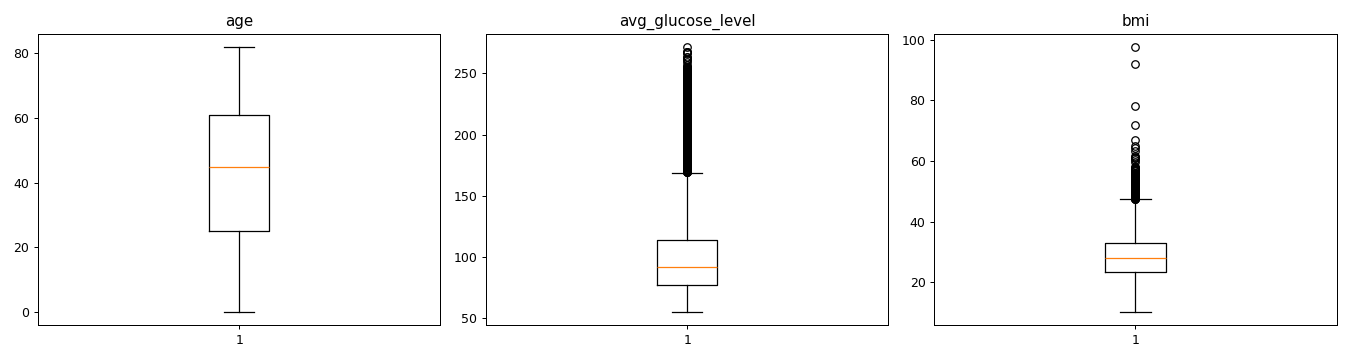

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['age', 'avg_glucose_level', 'bmi']):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [1]:
# ¿Los valores atípicos reflejan mayor riesgo real de stroke, o son ruido en los datos?
for col in ['avg_glucose_level', 'bmi']:
    outliers, li, ls = detectar_outliers_iqr(df, col)
    es_atipico = (df[col] < li) | (df[col] > ls)

    tasa_atipicos = df.loc[es_atipico, 'stroke'].mean()
    tasa_normales = df.loc[~es_atipico, 'stroke'].mean()
    print(f"{col}: tasa de stroke en atípicos={tasa_atipicos:.4f}  |  tasa de stroke en valores normales={tasa_normales:.4f}")

avg_glucose_level: tasa de stroke en atípicos=0.1340  |  tasa de stroke en valores normales=0.0368
bmi: tasa de stroke en atípicos=0.0182  |  tasa de stroke en valores normales=0.0494


**Observación:** los registros con `avg_glucose_level` atípico presentan una mayor proporción de `stroke = 1` que los registros dentro del rango normal.

Por esta razón, los valores atípicos no se eliminan, ya que podrían contener información relevante para la clasificación y su eliminación reduciría información disponible, especialmente sobre la clase minoritaria.

In [7]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

print("\nColumnas:")
print(df.columns.tolist())

print("\nInformación general:")
df.info()

Filas: 5110
Columnas: 12

Columnas:
['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dty

In [8]:
print("Valores nulos:")
print(df.isnull().sum())

print("\nRegistros duplicados:")
print(df.duplicated().sum())

Valores nulos:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Registros duplicados:
0


### Calidad de los datos

Se encontraron 201 valores faltantes en `bmi` y no se encontraron registros duplicados.

In [9]:
print("Cantidad por clase:")
print(df['stroke'].value_counts())

print("\nPorcentaje por clase:")
print(df['stroke'].value_counts(normalize=True) * 100)

Cantidad por clase:
stroke
0    4861
1     249
Name: count, dtype: int64

Porcentaje por clase:
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


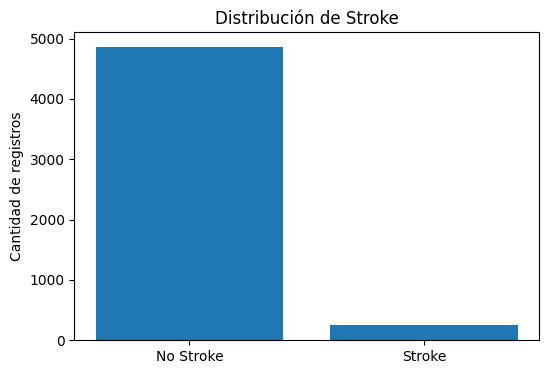

In [10]:
conteo = df['stroke'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(['No Stroke', 'Stroke'], conteo.values)

plt.title('Distribución de Stroke')
plt.ylabel('Cantidad de registros')

plt.show()

### Desbalance de clases

La clase `stroke = 1` representa aproximadamente el 4.87 % de los datos, por lo que existe un fuerte desbalance entre las clases.

In [11]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [12]:
variables_categoricas = df.select_dtypes(include='object').columns

for columna in variables_categoricas:
    print("\n", columna)
    print(df[columna].value_counts())


 gender
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

 ever_married
ever_married
Yes    3353
No     1757
Name: count, dtype: int64

 work_type
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

 Residence_type
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

 smoking_status
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


### Variables categóricas

Las variables categóricas deberán convertirse a valores numéricos antes de entrenar la Red Neuronal. Para ello se utilizará `OneHotEncoder` de Scikit-Learn.

In [13]:
df.groupby('stroke')[
    [
        'age',
        'avg_glucose_level',
        'bmi',
        'hypertension',
        'heart_disease'
    ]
].mean()

,age,avg_glucose_level,bmi,hypertension,heart_disease
stroke,,,,,
0,41.971545,104.795513,28.823064,0.088871,0.047110
1,67.728193,132.544739,30.471292,0.265060,0.188755


### Observación

Los pacientes de la clase `stroke = 1` presentan mayores valores promedio en varias de las características analizadas. Esto indica que existen diferencias que el modelo puede intentar aprender.

# 4. Preparación de los Datos

Se separará la variable objetivo de las variables predictoras y se realizará una división estratificada entre entrenamiento y prueba.

In [ ]:
# Separar variables predictoras y variable objetivo

X = df.drop(columns=['id', 'stroke'])
y = df['stroke']

print("X:", X.shape)
print("y:", y.shape)

X: (5110, 10)
y: (5110,)


In [ ]:
from sklearn.model_selection import train_test_split

SEED = 7

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

print("\nClases en entrenamiento:")
print(y_train.value_counts())

print("\nClases en prueba:")
print(y_test.value_counts())

Entrenamiento: (3577, 10)
Prueba: (1533, 10)

Clases en entrenamiento:
stroke
0    3403
1     174
Name: count, dtype: int64

Clases en prueba:
stroke
0    1458
1      75
Name: count, dtype: int64


La división se realizó de forma estratificada para conservar la proporción de las clases en entrenamiento y prueba.

In [ ]:
variables_continuas = [
    'age',
    'avg_glucose_level',
    'bmi'
]

variables_binarias = [
    'hypertension',
    'heart_disease'
]

variables_categoricas = [
    'gender',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
]

print("Continuas:", variables_continuas)
print("Binarias:", variables_binarias)
print("Categóricas:", variables_categoricas)

Continuas: ['age', 'avg_glucose_level', 'bmi']
Binarias: ['hypertension', 'heart_disease']
Categóricas: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

### Justificación de la arquitectura

Se utiliza una `MLPClassifier` con **una capa oculta de 50 neuronas**, activación **ReLU** y optimizador **Adam**, como punto de partida razonable dado el tamaño del dataset (~5000 registros y 21 características después del preprocesamiento): una sola capa oculta con un número moderado de neuronas suele ser suficiente para capturar relaciones no lineales sin incurrir en un riesgo alto de sobreajuste por exceso de parámetros.

Esta arquitectura se mantiene **idéntica en los tres modelos** de forma intencional, para que las diferencias en el desempeño puedan atribuirse exclusivamente al tratamiento de los datos (imputación/codificación, escalado, balanceo) y no a cambios en la red neuronal. Explorar variaciones de arquitectura queda fuera del alcance de este proyecto, cuyo objetivo es comparar tratamientos de datos.

# 5. Modelo 1 - Tratamiento Base

El primer modelo utilizará:

- Imputación de `bmi` mediante la mediana.
- One-Hot Encoding para variables categóricas.
- Sin escalado.
- Sin balanceo.

In [ ]:
tratamiento_numerico_1 = Pipeline([
    ('imputador', SimpleImputer(strategy='median'))
])

tratamiento_categorico_1 = Pipeline([
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

preprocesador_1 = ColumnTransformer([
    (
        'numericas',
        tratamiento_numerico_1,
        variables_continuas + variables_binarias
    ),
    (
        'categoricas',
        tratamiento_categorico_1,
        variables_categoricas
    )
])

In [ ]:
X_train_1 = preprocesador_1.fit_transform(X_train)
X_test_1 = preprocesador_1.transform(X_test)

print("Train transformado:", X_train_1.shape)
print("Test transformado:", X_test_1.shape)

print("NaN train:", np.isnan(X_train_1).sum())
print("NaN test:", np.isnan(X_test_1).sum())

Train transformado: (3577, 21)
Test transformado: (1533, 21)
NaN train: 0
NaN test: 0


### Arquitectura

Se utilizará una red `MLPClassifier` con una capa oculta de 50 neuronas, activación ReLU y optimizador Adam.

La misma arquitectura se mantendrá en los tres modelos para comparar únicamente el efecto del tratamiento de los datos.

In [ ]:
modelo_1 = MLPClassifier(
    hidden_layer_sizes=(50,),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    alpha=1e-12,
    tol=1e-12,
    max_iter=500,
    random_state=SEED
)

In [ ]:
modelo_1.fit(X_train_1, y_train)

print("Iteraciones:", modelo_1.n_iter_)
print("Pérdida final:", modelo_1.loss_)

Iteraciones: 47
Pérdida final: 0.16958357944595537


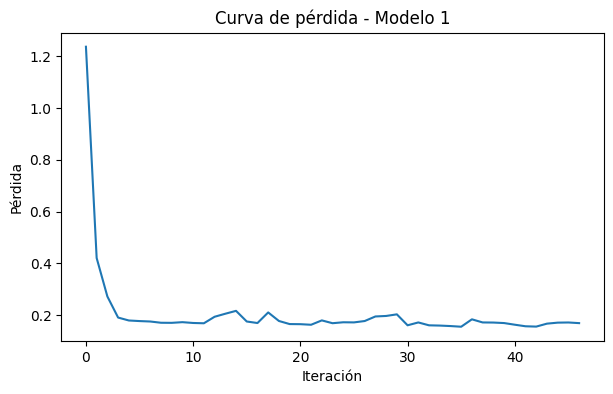

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(modelo_1.loss_curve_)

plt.title('Curva de pérdida - Modelo 1')
plt.xlabel('Iteración')
plt.ylabel('Pérdida')

plt.show()

In [ ]:
y_pred_1 = modelo_1.predict(X_test_1)
y_prob_1 = modelo_1.predict_proba(X_test_1)[:, 1]

In [ ]:
accuracy_1 = accuracy_score(y_test, y_pred_1)
precision_1 = precision_score(y_test, y_pred_1, zero_division=0)
recall_1 = recall_score(y_test, y_pred_1, zero_division=0)
f1_1 = f1_score(y_test, y_pred_1, zero_division=0)
auc_1 = roc_auc_score(y_test, y_prob_1)

print("MODELO 1")
print("Accuracy :", round(accuracy_1, 4))
print("Precision:", round(precision_1, 4))
print("Recall   :", round(recall_1, 4))
print("F1-Score :", round(f1_1, 4))
print("AUC-ROC  :", round(auc_1, 4))

MODELO 1
Accuracy : 0.9511
Precision: 0.0
Recall   : 0.0
F1-Score : 0.0
AUC-ROC  : 0.7246


In [ ]:
print(classification_report(
    y_test,
    y_pred_1,
    target_names=['No Stroke', 'Stroke'],
    zero_division=0
))

              precision    recall  f1-score   support

   No Stroke       0.95      1.00      0.97      1458
      Stroke       0.00      0.00      0.00        75

    accuracy                           0.95      1533
   macro avg       0.48      0.50      0.49      1533
weighted avg       0.90      0.95      0.93      1533



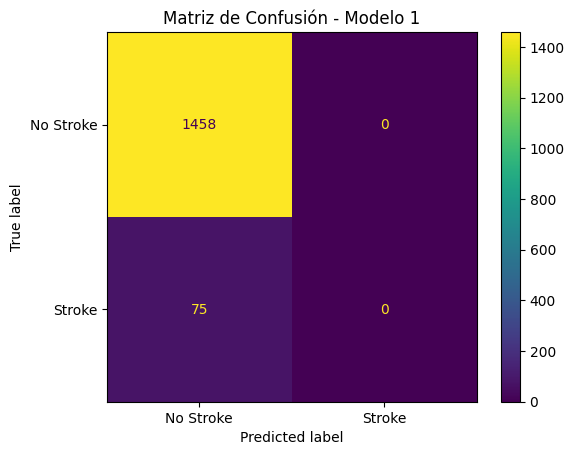

In [ ]:
matriz_1 = confusion_matrix(y_test, y_pred_1)

ConfusionMatrixDisplay(
    confusion_matrix=matriz_1,
    display_labels=['No Stroke', 'Stroke']
).plot()

plt.title('Matriz de Confusión - Modelo 1')
plt.show()

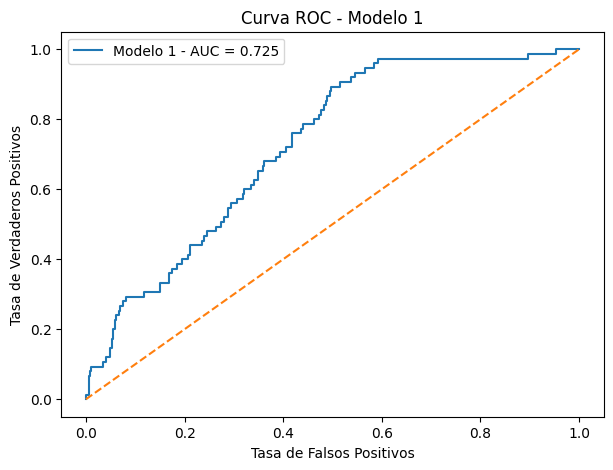

In [ ]:
fpr_1, tpr_1, _ = roc_curve(y_test, y_prob_1)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_1,
    tpr_1,
    label=f'Modelo 1 - AUC = {auc_1:.3f}'
)

plt.plot([0, 1], [0, 1], '--')

plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Modelo 1')
plt.legend()

plt.show()

### Resultado

El Modelo 1 se utilizará como línea base para comparar los siguientes tratamientos.

In [ ]:
resultados_modelo_1 = {
    'Modelo': 'Modelo 1 - Base',
    'Accuracy': accuracy_1,
    'Precision': precision_1,
    'Recall': recall_1,
    'F1-Score': f1_1,
    'AUC-ROC': auc_1
}

# 6. Modelo 2 - Escalado

El segundo modelo mantiene la misma arquitectura, pero añade escalado a las variables numéricas continuas.

In [ ]:
tratamiento_continuo_2 = Pipeline([
    ('imputador', SimpleImputer(strategy='median')),
    ('escalador', StandardScaler())
])

tratamiento_categorico_2 = Pipeline([
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

preprocesador_2 = ColumnTransformer([
    (
        'continuas',
        tratamiento_continuo_2,
        variables_continuas
    ),
    (
        'binarias',
        'passthrough',
        variables_binarias
    ),
    (
        'categoricas',
        tratamiento_categorico_2,
        variables_categoricas
    )
])

In [ ]:
X_train_2 = preprocesador_2.fit_transform(X_train)
X_test_2 = preprocesador_2.transform(X_test)

print("Train:", X_train_2.shape)
print("Test:", X_test_2.shape)

print("NaN train:", np.isnan(X_train_2).sum())
print("NaN test:", np.isnan(X_test_2).sum())

Train: (3577, 21)
Test: (1533, 21)
NaN train: 0
NaN test: 0


In [ ]:
modelo_2 = MLPClassifier(
    hidden_layer_sizes=(50,),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    alpha=1e-12,
    tol=1e-12,
    max_iter=500,
    random_state=SEED
)

modelo_2.fit(X_train_2, y_train)

print("Iteraciones:", modelo_2.n_iter_)
print("Pérdida final:", modelo_2.loss_)

Iteraciones: 206
Pérdida final: 0.06847526602277174


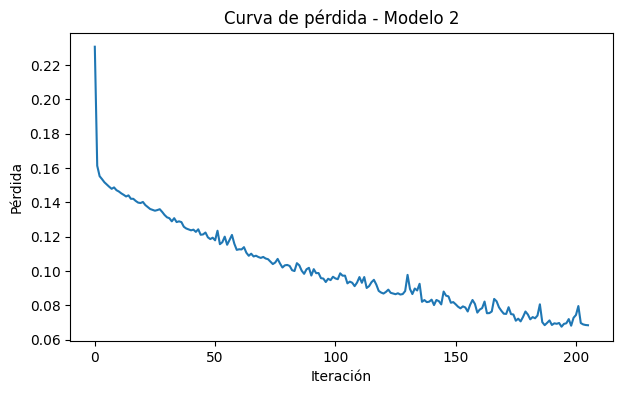

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(modelo_2.loss_curve_)

plt.title('Curva de pérdida - Modelo 2')
plt.xlabel('Iteración')
plt.ylabel('Pérdida')

plt.show()

In [ ]:
y_pred_2 = modelo_2.predict(X_test_2)
y_prob_2 = modelo_2.predict_proba(X_test_2)[:, 1]

accuracy_2 = accuracy_score(y_test, y_pred_2)
precision_2 = precision_score(y_test, y_pred_2, zero_division=0)
recall_2 = recall_score(y_test, y_pred_2, zero_division=0)
f1_2 = f1_score(y_test, y_pred_2, zero_division=0)
auc_2 = roc_auc_score(y_test, y_prob_2)

print("MODELO 2")
print("Accuracy :", round(accuracy_2, 4))
print("Precision:", round(precision_2, 4))
print("Recall   :", round(recall_2, 4))
print("F1-Score :", round(f1_2, 4))
print("AUC-ROC  :", round(auc_2, 4))

MODELO 2
Accuracy : 0.9295
Precision: 0.1633
Recall   : 0.1067
F1-Score : 0.129
AUC-ROC  : 0.7329


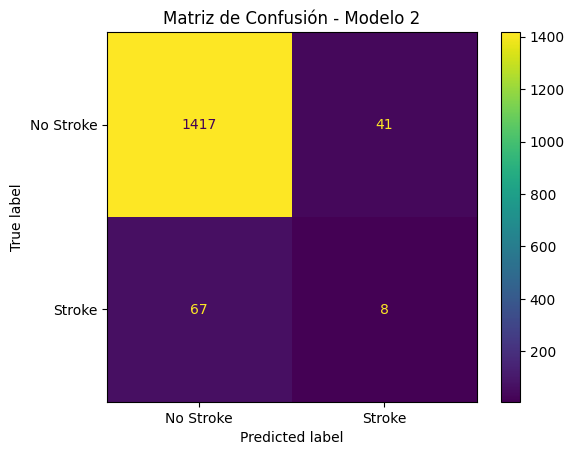

[[1417   41]
 [  67    8]]


In [ ]:
matriz_2 = confusion_matrix(y_test, y_pred_2)

ConfusionMatrixDisplay(
    confusion_matrix=matriz_2,
    display_labels=['No Stroke', 'Stroke']
).plot()

plt.title('Matriz de Confusión - Modelo 2')
plt.show()

print(matriz_2)

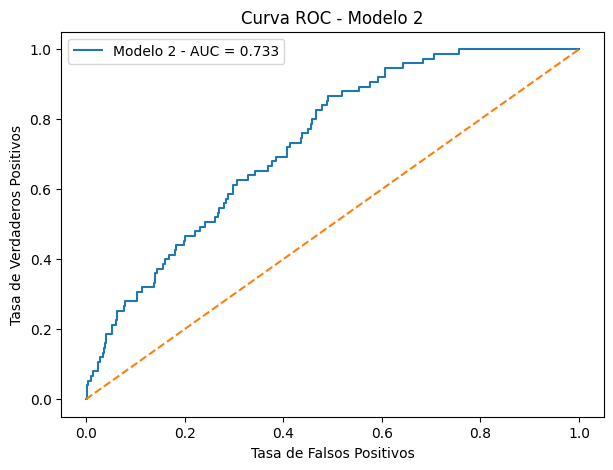

In [ ]:
fpr_2, tpr_2, _ = roc_curve(y_test, y_prob_2)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_2,
    tpr_2,
    label=f'Modelo 2 - AUC = {auc_2:.3f}'
)

plt.plot([0, 1], [0, 1], '--')

plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Modelo 2')
plt.legend()

plt.show()

In [ ]:
resultados_modelo_2 = {
    'Modelo': 'Modelo 2 - Escalado',
    'Accuracy': accuracy_2,
    'Precision': precision_2,
    'Recall': recall_2,
    'F1-Score': f1_2,
    'AUC-ROC': auc_2
}

### Resultado

El Modelo 2 permite evaluar el efecto del escalado frente al tratamiento base.

# 7. Modelo 3 - Balanceo

El tercer modelo mantiene el escalado del Modelo 2 y agrega balanceo de la clase minoritaria mediante Random Oversampling.

In [ ]:
from sklearn.utils import resample, shuffle

y_train_array = y_train.to_numpy()

X_mayoria = X_train_2[y_train_array == 0]
y_mayoria = y_train_array[y_train_array == 0]

X_minoria = X_train_2[y_train_array == 1]
y_minoria = y_train_array[y_train_array == 1]

X_minoria_bal, y_minoria_bal = resample(
    X_minoria,
    y_minoria,
    replace=True,
    n_samples=len(y_mayoria),
    random_state=SEED
)

X_train_3 = np.concatenate(
    [X_mayoria, X_minoria_bal]
)

y_train_3 = np.concatenate(
    [y_mayoria, y_minoria_bal]
)

X_train_3, y_train_3 = shuffle(
    X_train_3,
    y_train_3,
    random_state=SEED
)

print("Clase 0:", np.sum(y_train_3 == 0))
print("Clase 1:", np.sum(y_train_3 == 1))

Clase 0: 3403
Clase 1: 3403


In [ ]:
modelo_3 = MLPClassifier(
    hidden_layer_sizes=(50,),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    alpha=1e-12,
    tol=1e-12,
    max_iter=500,
    random_state=SEED
)

modelo_3.fit(X_train_3, y_train_3)

print("Iteraciones:", modelo_3.n_iter_)
print("Pérdida final:", modelo_3.loss_)

Iteraciones: 209
Pérdida final: 0.05771267123181273


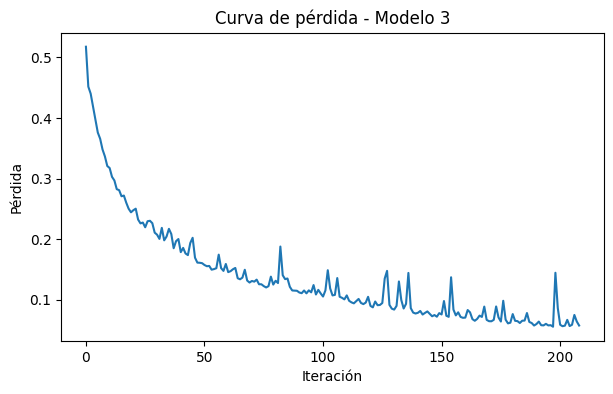

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(modelo_3.loss_curve_)

plt.title('Curva de pérdida - Modelo 3')
plt.xlabel('Iteración')
plt.ylabel('Pérdida')

plt.show()

In [ ]:
y_pred_3 = modelo_3.predict(X_test_2)
y_prob_3 = modelo_3.predict_proba(X_test_2)[:, 1]

accuracy_3 = accuracy_score(y_test, y_pred_3)
precision_3 = precision_score(y_test, y_pred_3, zero_division=0)
recall_3 = recall_score(y_test, y_pred_3, zero_division=0)
f1_3 = f1_score(y_test, y_pred_3, zero_division=0)
auc_3 = roc_auc_score(y_test, y_prob_3)

print("MODELO 3")
print("Accuracy :", round(accuracy_3, 4))
print("Precision:", round(precision_3, 4))
print("Recall   :", round(recall_3, 4))
print("F1-Score :", round(f1_3, 4))
print("AUC-ROC  :", round(auc_3, 4))

MODELO 3
Accuracy : 0.8943
Precision: 0.1217
Recall   : 0.1867
F1-Score : 0.1474
AUC-ROC  : 0.7442


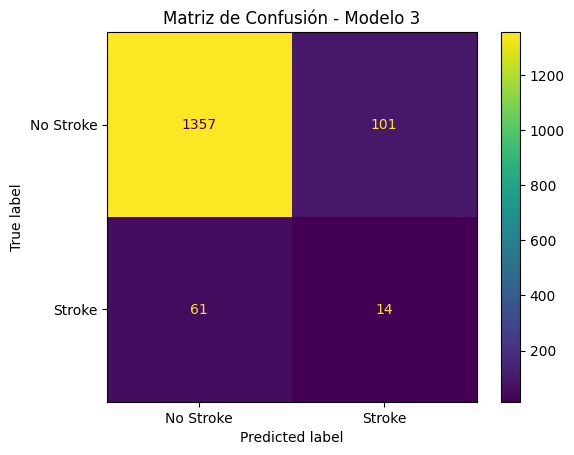

[[1357  101]
 [  61   14]]


In [ ]:
matriz_3 = confusion_matrix(y_test, y_pred_3)

ConfusionMatrixDisplay(
    confusion_matrix=matriz_3,
    display_labels=['No Stroke', 'Stroke']
).plot()

plt.title('Matriz de Confusión - Modelo 3')
plt.show()

print(matriz_3)

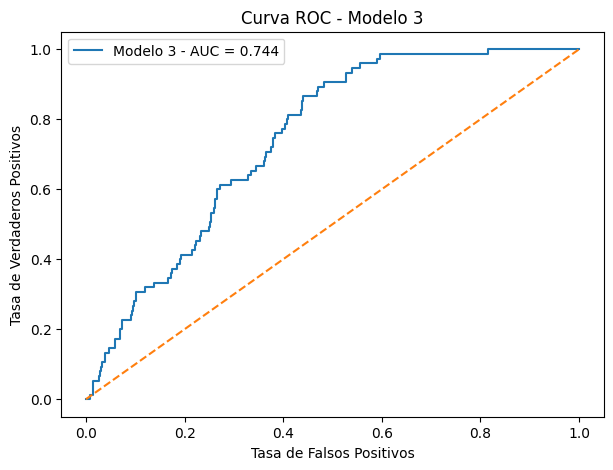

In [ ]:
fpr_3, tpr_3, _ = roc_curve(y_test, y_prob_3)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_3,
    tpr_3,
    label=f'Modelo 3 - AUC = {auc_3:.3f}'
)

plt.plot([0, 1], [0, 1], '--')

plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Modelo 3')
plt.legend()

plt.show()

In [ ]:
resultados_modelo_3 = {
    'Modelo': 'Modelo 3 - Balanceo',
    'Accuracy': accuracy_3,
    'Precision': precision_3,
    'Recall': recall_3,
    'F1-Score': f1_3,
    'AUC-ROC': auc_3
}

### Resultado

El Modelo 3 permite evaluar si el balanceo mejora la detección de la clase `stroke = 1`.

# 8. Comparación de Modelos

Se comparan los tres tratamientos utilizando Accuracy, Precision, Recall, F1-Score y AUC-ROC.

In [ ]:
resultados = pd.DataFrame([
    resultados_modelo_1,
    resultados_modelo_2,
    resultados_modelo_3
])

resultados.set_index('Modelo', inplace=True)

resultados.round(4)

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Modelo,,,,,
Modelo 1 - Base,0.9511,0.0000,0.0000,0.0000,0.7246
Modelo 2 - Escalado,0.9295,0.1633,0.1067,0.1290,0.7329
Modelo 3 - Balanceo,0.8943,0.1217,0.1867,0.1474,0.7442


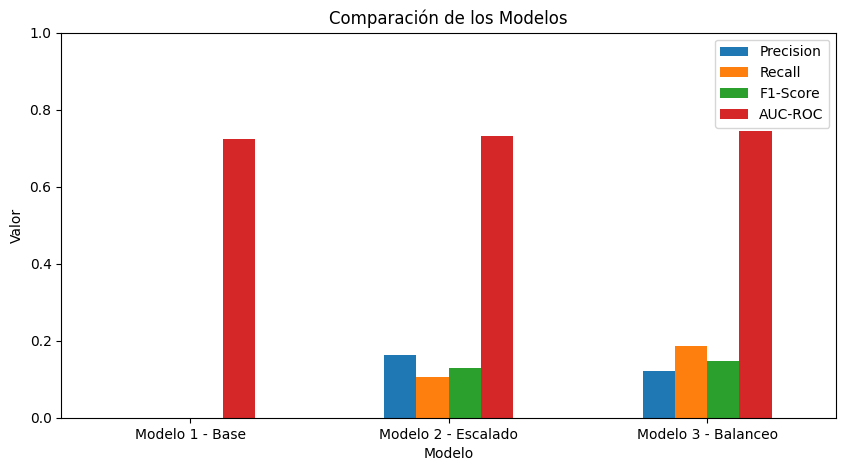

In [ ]:
metricas_comparacion = resultados[
    ['Precision', 'Recall', 'F1-Score', 'AUC-ROC']
]

metricas_comparacion.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Comparación de los Modelos')
plt.ylabel('Valor')
plt.xlabel('Modelo')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='upper right')

plt.show()

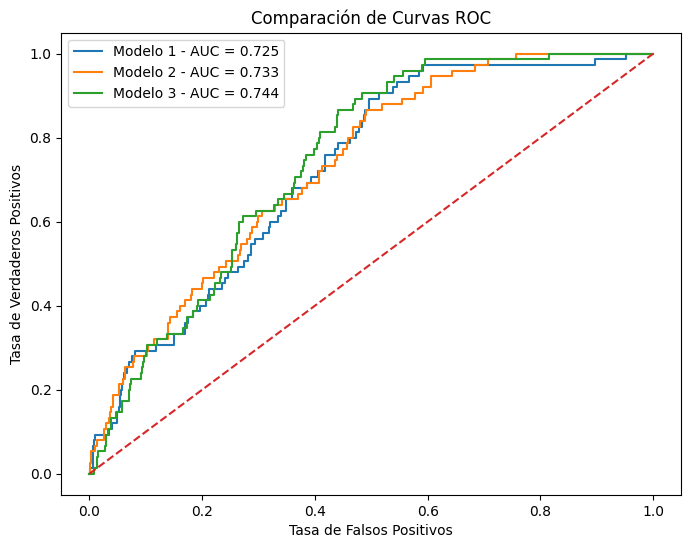

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_1,
    tpr_1,
    label=f'Modelo 1 - AUC = {auc_1:.3f}'
)

plt.plot(
    fpr_2,
    tpr_2,
    label=f'Modelo 2 - AUC = {auc_2:.3f}'
)

plt.plot(
    fpr_3,
    tpr_3,
    label=f'Modelo 3 - AUC = {auc_3:.3f}'
)

plt.plot([0, 1], [0, 1], '--')

plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Comparación de Curvas ROC')
plt.legend()

plt.show()

# 9. Selección del Modelo

Debido al fuerte desbalance del dataset, la selección no se basa únicamente en Accuracy. Se da mayor importancia a Recall, F1-Score y AUC-ROC para evaluar la detección de la clase `stroke = 1`.

### Modelo seleccionado

Se selecciona el **Modelo 3 - Balanceo**, ya que obtuvo los mejores resultados en las métricas priorizadas para la clase `stroke = 1`:

- Recall: 0.1867
- F1-Score: 0.1474
- AUC-ROC: 0.7442

El Modelo 1 obtuvo la mayor Accuracy (0.9511), pero presentó Recall = 0, por lo que no logró identificar casos positivos en el conjunto de prueba.

El Modelo 2 logró detectar algunos casos positivos, pero el Modelo 3 obtuvo los mejores valores de Recall, F1-Score y AUC-ROC. Por esta razón, se selecciona el Modelo 3 para continuar con la validación y el despliegue.

# 10. Validación del Modelo Seleccionado

Antes de pasar a la fase de despliegue, se evalúa la consistencia del Modelo 3 mediante validación cruzada y se verifica si existe sobreajuste comparando su desempeño en entrenamiento y prueba.

### Validación cruzada

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import resample, shuffle

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

acc_cv, prec_cv, rec_cv, f1_cv_list, auc_cv = [], [], [], [], []

for train_idx, val_idx in cv.split(X, y):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Preprocesamiento ajustado solo con el fold de entrenamiento (igual que el Modelo 2)
    preprocesador_fold = ColumnTransformer([
        (
            'continuas',
            Pipeline([
                ('imputador', SimpleImputer(strategy='median')),
                ('escalador', StandardScaler())
            ]),
            variables_continuas
        ),
        ('binarias', 'passthrough', variables_binarias),
        (
            'categoricas',
            Pipeline([
                ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
            ]),
            variables_categoricas
        )
    ])

    X_tr_proc = preprocesador_fold.fit_transform(X_tr)
    X_val_proc = preprocesador_fold.transform(X_val)

    # Balanceo mediante Random Oversampling mismo procedimiento que el Modelo 3
    y_tr_array = y_tr.to_numpy()

    X_mayoria_f = X_tr_proc[y_tr_array == 0]
    y_mayoria_f = y_tr_array[y_tr_array == 0]

    X_minoria_f = X_tr_proc[y_tr_array == 1]
    y_minoria_f = y_tr_array[y_tr_array == 1]

    X_minoria_bal_f, y_minoria_bal_f = resample(
        X_minoria_f,
        y_minoria_f,
        replace=True,
        n_samples=len(y_mayoria_f),
        random_state=SEED
    )

    X_tr_bal = np.concatenate([X_mayoria_f, X_minoria_bal_f])
    y_tr_bal = np.concatenate([y_mayoria_f, y_minoria_bal_f])

    X_tr_bal, y_tr_bal = shuffle(X_tr_bal, y_tr_bal, random_state=SEED)

    # Entrenamiento con la misma arquitectura del Modelo 3
    modelo_fold = MLPClassifier(
        hidden_layer_sizes=(50,),
        activation='relu',
        solver='adam',
        learning_rate_init=0.01,
        alpha=1e-12,
        tol=1e-12,
        max_iter=500,
        random_state=SEED
    )
    modelo_fold.fit(X_tr_bal, y_tr_bal)

    y_pred_val = modelo_fold.predict(X_val_proc)
    y_prob_val = modelo_fold.predict_proba(X_val_proc)[:, 1]

    acc_cv.append(accuracy_score(y_val, y_pred_val))
    prec_cv.append(precision_score(y_val, y_pred_val, zero_division=0))
    rec_cv.append(recall_score(y_val, y_pred_val, zero_division=0))
    f1_cv_list.append(f1_score(y_val, y_pred_val, zero_division=0))
    auc_cv.append(roc_auc_score(y_val, y_prob_val))

print("VALIDACIÓN CRUZADA - MODELO 3 (5 particiones, con resample por fold)")
print("Accuracy promedio :", round(np.mean(acc_cv), 4))
print("Precision promedio:", round(np.mean(prec_cv), 4))
print("Recall promedio   :", round(np.mean(rec_cv), 4))
print("F1 promedio       :", round(np.mean(f1_cv_list), 4))
print("AUC-ROC promedio  :", round(np.mean(auc_cv), 4))

VALIDACIÓN CRUZADA - MODELO 3 (5 particiones, con resample por fold)
Accuracy promedio : 0.8834
Precision promedio: 0.1144
Recall promedio   : 0.2049
F1 promedio       : 0.1464
AUC-ROC promedio  : 0.7262


La validación cruzada obtuvo un Recall promedio de 0.2049 y un F1 promedio de 0.1464, valores cercanos a los obtenidos en el conjunto de prueba original (Recall 0.1867 y F1 0.1474).

Esto sugiere que el comportamiento del Modelo 3 es relativamente consistente entre diferentes particiones de los datos.

### Verificación de sobreajuste

In [ ]:
y_pred_train_3 = modelo_3.predict(X_train_2)
recall_train_3 = recall_score(y_train, y_pred_train_3, zero_division=0)
f1_train_3 = f1_score(y_train, y_pred_train_3, zero_division=0)

print("COMPARACIÓN ENTRENAMIENTO vs PRUEBA - MODELO 3")
print(f"Recall entrenamiento: {recall_train_3:.4f}   Recall prueba: {recall_3:.4f}")
print(f"F1 entrenamiento    : {f1_train_3:.4f}   F1 prueba    : {f1_3:.4f}")

COMPARACIÓN ENTRENAMIENTO vs PRUEBA - MODELO 3
Recall entrenamiento: 1.0000   Recall prueba: 0.1867
F1 entrenamiento    : 0.8131   F1 prueba    : 0.1474


Existe evidencia clara de sobreajuste: el Recall en entrenamiento es 1.0000 y el F1 es 0.8131, mientras que en prueba disminuyen a 0.1867 y 0.1474 respectivamente.

El Random Oversampling puede favorecer este comportamiento al reutilizar ejemplos de la clase minoritaria. Aunque el Modelo 3 sigue presentando los mejores resultados entre los tres modelos evaluados, esta diferencia entre entrenamiento y prueba constituye una limitación importante.

# 11. Fase de Despliegue

Se ensambla un **Pipeline de inferencia** que combina el preprocesamiento ya ajustado del Modelo 2 con la red neuronal del Modelo 3, previamente entrenada sobre los datos balanceados.

Este Pipeline permite aplicar automáticamente el preprocesamiento necesario y realizar predicciones sobre nuevos registros.

In [ ]:
modelo_final = Pipeline([
    ('preprocesamiento', preprocesador_2),
    ('red_neuronal', modelo_3)
])

print("Pipeline final ensamblado: preprocesamiento del Modelo 2 (escalado) + red neuronal del Modelo 3 (balanceo).")

Pipeline final ensamblado: preprocesamiento del Modelo 2 (escalado) + red neuronal del Modelo 3 (balanceo).


No es necesario volver a entrenar el pipeline: `preprocesador_2` y `modelo_3` ya fueron ajustados anteriormente (el segundo, sobre los datos balanceados). Llamar `.fit()` de nuevo aquí sobreescribiría el balanceo y reproduciría el comportamiento del Modelo 2, no del Modelo 3.

In [ ]:
y_pred_final = modelo_final.predict(X_test)
y_prob_final = modelo_final.predict_proba(X_test)[:, 1]

accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(
    y_test,
    y_pred_final,
    zero_division=0
)
recall_final = recall_score(
    y_test,
    y_pred_final,
    zero_division=0
)
f1_final = f1_score(
    y_test,
    y_pred_final,
    zero_division=0
)
auc_final = roc_auc_score(y_test, y_prob_final)

print("MODELO FINAL")
print("Accuracy :", round(accuracy_final, 4))
print("Precision:", round(precision_final, 4))
print("Recall   :", round(recall_final, 4))
print("F1-Score :", round(f1_final, 4))
print("AUC-ROC  :", round(auc_final, 4))

MODELO FINAL
Accuracy : 0.8943
Precision: 0.1217
Recall   : 0.1867
F1-Score : 0.1474
AUC-ROC  : 0.7442


### Predicción de un nuevo paciente

Se realiza una prueba con un nuevo registro utilizando las mismas variables presentes en el dataset.

In [ ]:
paciente_nuevo = pd.DataFrame({
    'gender': ['Male'],
    'age': [67.0],
    'hypertension': [1],
    'heart_disease': [1],
    'ever_married': ['Yes'],
    'work_type': ['Private'],
    'Residence_type': ['Urban'],
    'avg_glucose_level': [228.69],
    'bmi': [36.6],
    'smoking_status': ['formerly smoked']
})

paciente_nuevo

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,Male,67.0,1,1,Yes,Private,Urban,228.69,36.6,formerly smoked


In [ ]:
prediccion = modelo_final.predict(
    paciente_nuevo
)[0]

probabilidad = modelo_final.predict_proba(
    paciente_nuevo
)[0][1]

if prediccion == 1:
    print("Clasificación del modelo: Stroke")
else:
    print("Clasificación del modelo: No Stroke")

print(
    "Probabilidad estimada por el modelo:",
    round(probabilidad * 100, 2),
    "%"
)

Clasificación del modelo: Stroke
Probabilidad estimada por el modelo: 99.95 %


### Resultado

El Pipeline permite ingresar datos de un nuevo paciente y realizar automáticamente el preprocesamiento (imputación, escalado y codificación) y la clasificación con la red neuronal entrenada sobre datos balanceados.

La predicción corresponde únicamente al resultado del modelo desarrollado con fines académicos.

# 12. Conclusiones

Se desarrollaron tres redes neuronales con la misma arquitectura y diferentes tratamientos de los datos: imputación y codificación (Modelo 1), escalado adicional (Modelo 2), y balanceo de clases mediante Random Oversampling (Modelo 3).

El Modelo 1 alcanzó la mayor Accuracy (0.9511), pero un Recall de 0: no detectó ningún caso real de `stroke = 1` en el conjunto de prueba. Esto muestra que la Accuracy no es suficiente por sí sola para evaluar un problema con un desbalance de clases tan fuerte (95 % / 5 %).

El Modelo 3 fue seleccionado como modelo final, ya que obtuvo el mejor Recall (0.1867), F1-Score (0.1474) y AUC-ROC (0.7442) de los tres. La validación cruzada de 5 particiones obtuvo un Recall promedio de 0.2049 y un F1 promedio de 0.1464, lo que sugiere un comportamiento relativamente consistente entre diferentes particiones de los datos.

Sin embargo, la comparación entre entrenamiento y prueba reveló **sobreajuste severo** en el Modelo 3 (Recall de entrenamiento 1.0000 frente a Recall de prueba 0.1867). El Random Oversampling puede favorecer este comportamiento al reutilizar ejemplos de la clase minoritaria. El Modelo 3 sigue siendo la mejor opción entre los tres evaluados, pero esta diferencia constituye una limitación importante.

Finalmente, se construyó un Pipeline que integra el preprocesamiento y la red neuronal entrenada con datos balanceados para realizar predicciones sobre nuevos registros. En la demostración, el modelo clasificó al paciente de ejemplo como **Stroke**, con una probabilidad estimada del 99.95 %. Esta salida corresponde únicamente al modelo desarrollado con fines académicos.